In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler 

In [17]:
df_global = pd.read_csv('data/BostonHousing.csv')

df_global = df_global.rename(columns={
    'crim': 'crime_rate',           # Уровень преступности
    'zn': 'large_lots',              # Доля земли под большие участки
    'indus': 'industry',             # Доля промышленности
    'chas': 'river',                  # У реки (Charles river)
    'nox': 'nox_conc',       # Концентрация оксидов азота
    'rm': 'rooms_avg',                # Среднее число комнат
    'age': 'old_buildings',           # Доля старых домов (до 1940)
    'dis': 'center_dist',  # Расстояние до центров занятости
    'rad': 'highway',          # Доступ к шоссе
    'tax': 'property',            # Налог на недвижимость
    'ptratio': 'pupil_teacher', # Соотношение ученики/учитель
    'b': 'black_population',    # Индекс чернокожего населения 
    'lstat': 'lower_status',  # % населения с низким статусом
    'medv': 'price'                    # ЦЕЛЬ: медианная цена дома
})


In [18]:
df_global.shape

(506, 14)

In [19]:
df_global.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   crime_rate        506 non-null    float64
 1   large_lots        506 non-null    float64
 2   industry          506 non-null    float64
 3   river             506 non-null    int64  
 4   nox_conc          506 non-null    float64
 5   rooms_avg         501 non-null    float64
 6   old_buildings     506 non-null    float64
 7   center_dist       506 non-null    float64
 8   highway           506 non-null    int64  
 9   property          506 non-null    int64  
 10  pupil_teacher     506 non-null    float64
 11  black_population  506 non-null    float64
 12  lower_status      506 non-null    float64
 13  price             506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [20]:
df_global.describe().T

,count,mean,std,min,25%,50%,75%,max
crime_rate,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
large_lots,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
industry,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
river,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
nox_conc,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rooms_avg,501.0,6.284341,0.705587,3.56100,5.884000,6.20800,6.625000,8.7800
old_buildings,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
center_dist,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
highway,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
property,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [21]:
df_global.head()

,crime_rate,large_lots,industry,river,nox_conc,rooms_avg,old_buildings,center_dist,highway,property,pupil_teacher,black_population,lower_status,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


# Обучение модели на сырых данных

In [22]:
# Целевая переменная
X = df_global.drop('price', axis=1)
y = df_global['price']

# Делим на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model_raw = LinearRegression()
model_raw.fit(X_train, y_train)

print(f"Точность на тесте: {model_raw.score(X_test, y_test):.3f}")


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# 1. Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 2. Считаем медианы по каждому столбцу НА ТРЕНИРОВОЧНЫХ данных
medians = X_train.median()

print("Медианы для заполнения пропусков:")
print(medians[medians.isna()])  # Покажем только те, где есть пропуски

# 3. Заполняем пропуски в train
X_train_filled = X_train.fillna(medians)

# 4. Заполняем пропуски в test (ТЕМИ ЖЕ медианами!)
X_test_filled = X_test.fillna(medians)

# 5. Проверяем, что пропусков больше нет
print(f"\nПропуски в train после заполнения: {X_train_filled.isnull().sum().sum()}")
print(f"Пропуски в test после заполнения: {X_test_filled.isnull().sum().sum()}")

# 6. Обучаем модель
model = LinearRegression()
model.fit(X_train_filled, y_train)

# 7. Оцениваем качество
train_score = model.score(X_train_filled, y_train)
test_score = model.score(X_test_filled, y_test)

print(f"\nR² на train: {train_score:.3f}")
print(f"R² на test:  {test_score:.3f}")

Медианы для заполнения пропусков:
Series([], dtype: float64)

Пропуски в train после заполнения: 0
Пропуски в test после заполнения: 0

R² на train: 0.743
R² на test:  0.710


# Введение в EDA

## Блок 1. Общая информация

### 1 балл

In [ ]:
df_global.shape

### 1 балл

In [ ]:
df_global.columns

### 1 балл

In [ ]:
df_global.info()

### 1 балл

In [ ]:
df_global.describe()

## Блок 2. Подключаем общую статистику

### 3 балла

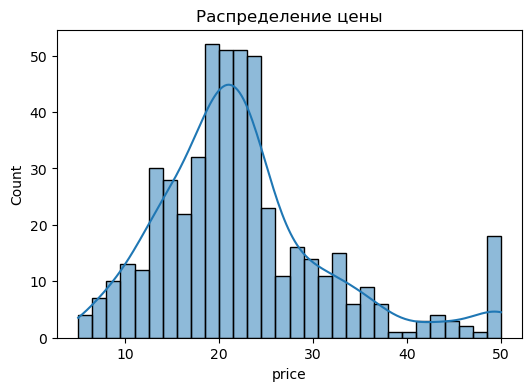

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(df_global['price'], bins=30, kde=True)
plt.title("Распределение цены")
plt.show()

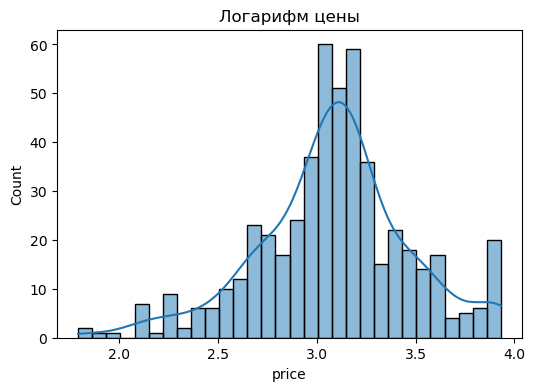

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(df_global['price']), bins=30, kde=True)
plt.title("Логарифм цены")
plt.show()

### 4 балла

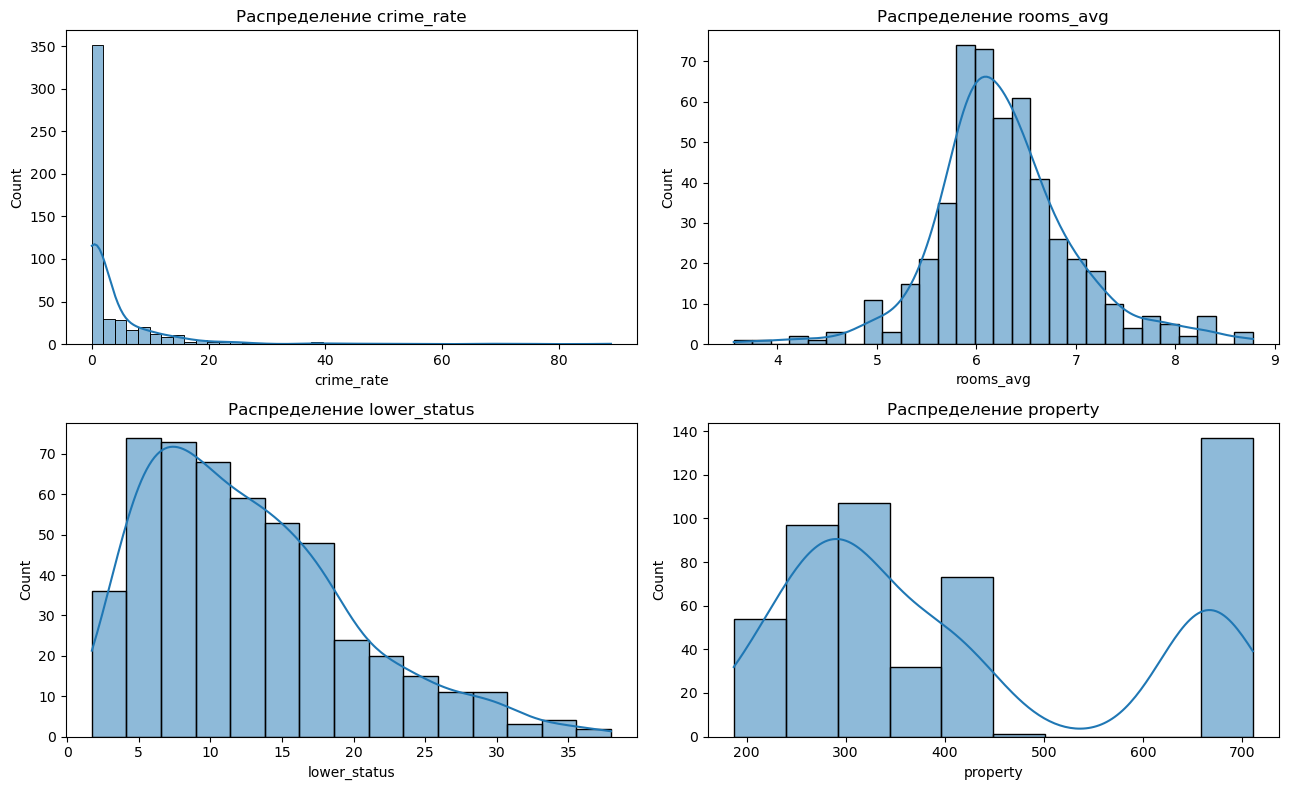

In [ ]:
selected_features = ['crime_rate', 'rooms_avg', 'lower_status', 'property']

fig, axes = plt.subplots(2, 2, figsize=(13, 8)) # fig - окно целиком, axes - список из 4 графиков
axes = axes.flatten() # flatten - сплющивание в одномерный массив

for i, col in enumerate(selected_features):
    sns.histplot(df_global[col], kde=True, ax=axes[i]) # kde - линия, ax - куда рисовать
    axes[i].set_title(f'Распределение {col}')

plt.tight_layout() # чтобы графики не налезали друг на друга
plt.show()

<Axes: xlabel='crime_rate', ylabel='Count'>

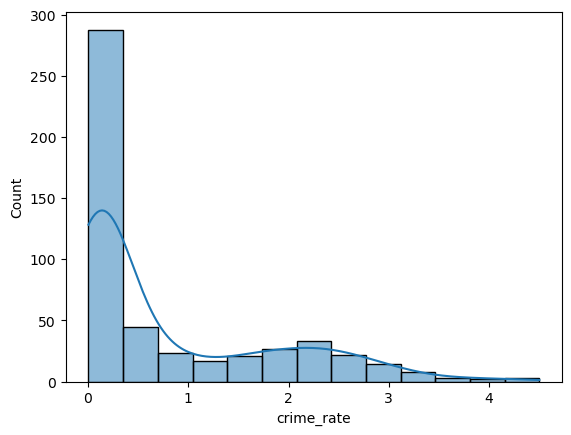

In [26]:
df_global['crime_rate'] =np.log1p(df_global['crime_rate'])
sns.histplot(df_global['crime_rate'], kde=True)

### 4 балла

<Axes: xlabel='crime_rate'>

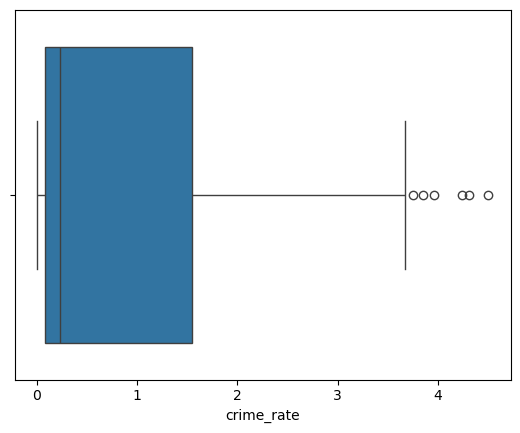

In [27]:
sns.boxplot(x=df_global['crime_rate'])

In [28]:
df_global = df_global[df_global['crime_rate'] < 4]

<Axes: xlabel='crime_rate'>

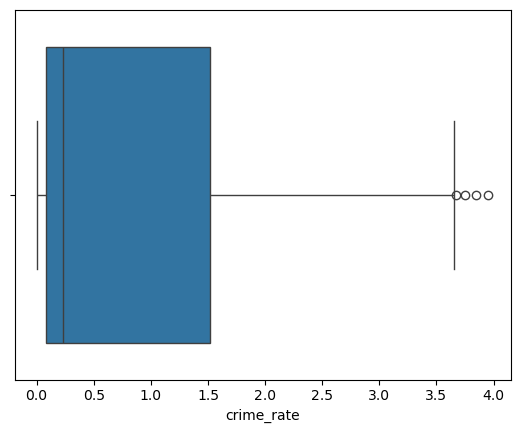

In [29]:
sns.boxplot(x=df_global['crime_rate'])

<Axes: xlabel='crime_rate', ylabel='Count'>

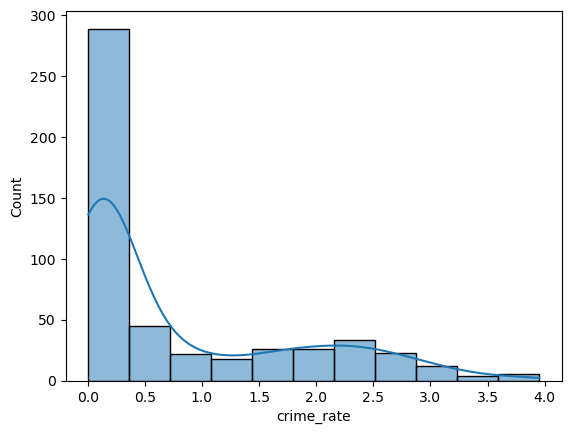

In [30]:
sns.histplot(df_global['crime_rate'], kde=True)

### 3 балла

In [31]:
df_global.corr()['price'].sort_values(ascending=False)

price               1.000000
rooms_avg           0.700758
large_lots          0.358846
black_population    0.331893
center_dist         0.242542
river               0.174062
old_buildings      -0.371208
highway            -0.371903
nox_conc           -0.421662
crime_rate         -0.451476
property           -0.460871
industry           -0.479294
pupil_teacher      -0.505025
lower_status       -0.735494
Name: price, dtype: float64

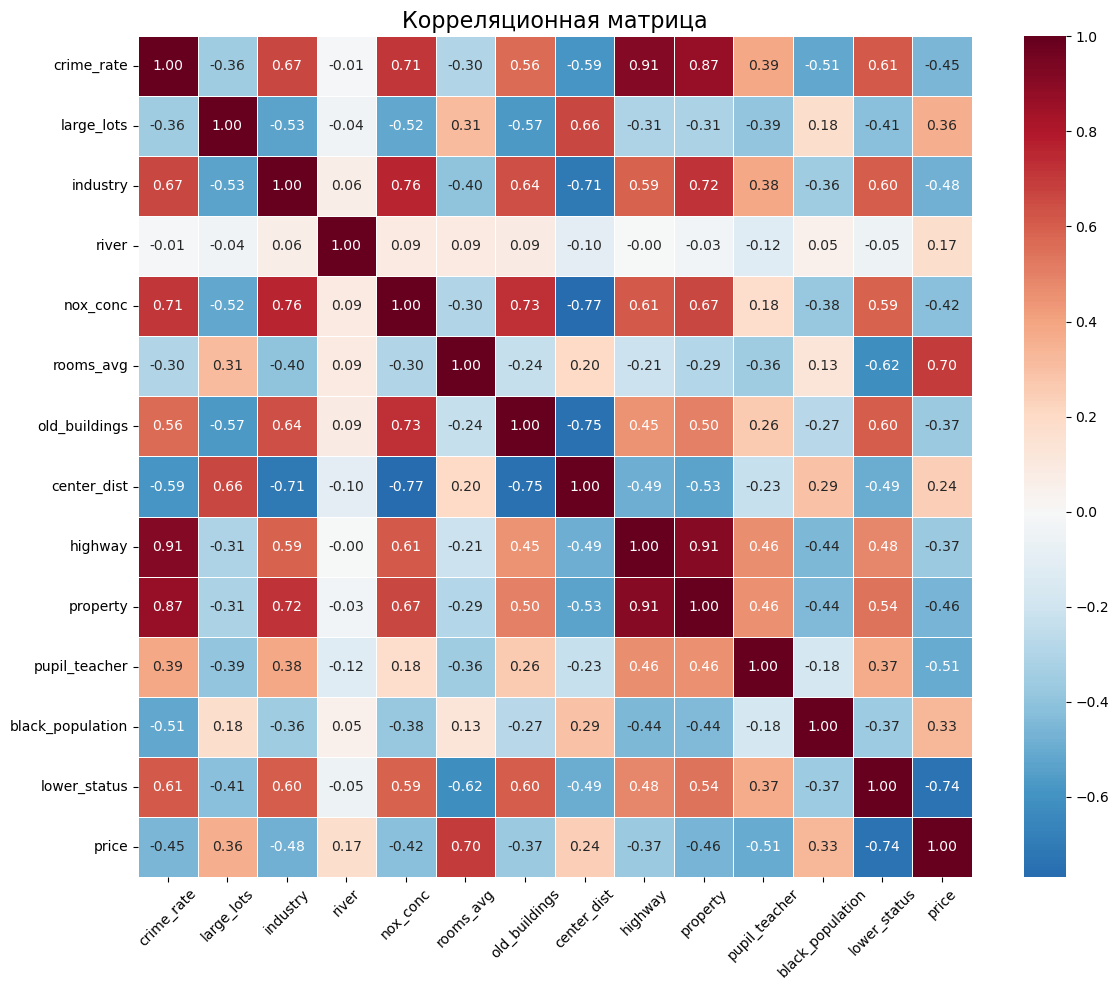

In [32]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    df_global.corr(),
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Корреляционная матрица', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 5 баллов

In [33]:
df_global.describe()

,crime_rate,large_lots,industry,river,nox_conc,rooms_avg,old_buildings,center_dist,highway,property,pupil_teacher,black_population,lower_status,price
count,503.000000,503.000000,503.000000,503.000000,503.000000,498.000000,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000
mean,0.792338,11.431412,11.095249,0.069583,0.553942,6.284833,68.403579,3.808444,9.463221,406.699801,18.445129,357.214195,12.607634,22.619085
std,0.988460,23.375438,6.859608,0.254695,0.115808,0.706381,28.143312,2.104749,8.661067,167.854339,2.167188,90.271083,7.135629,9.154425
min,0.006300,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.078746,0.000000,5.160000,0.000000,0.449000,5.884250,44.700000,2.105250,4.000000,279.000000,17.350000,375.425000,6.925000,17.100000
50%,0.225988,0.000000,9.690000,0.000000,0.538000,6.208500,77.000000,3.215700,5.000000,330.000000,19.000000,391.450000,11.320000,21.200000
75%,1.515526,12.500000,18.100000,0.000000,0.624000,6.623500,93.950000,5.213250,24.000000,666.000000,20.200000,396.220000,16.820000,25.000000
max,3.953852,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [34]:
numeric_features = ['crime_rate', 'large_lots', 'industry', 'river',  'nox_conc', 'rooms_avg', 'old_buildings', 'center_dist', 'highway', 'property', 'pupil_teacher', 'black_population', 'lower_status', 'price']

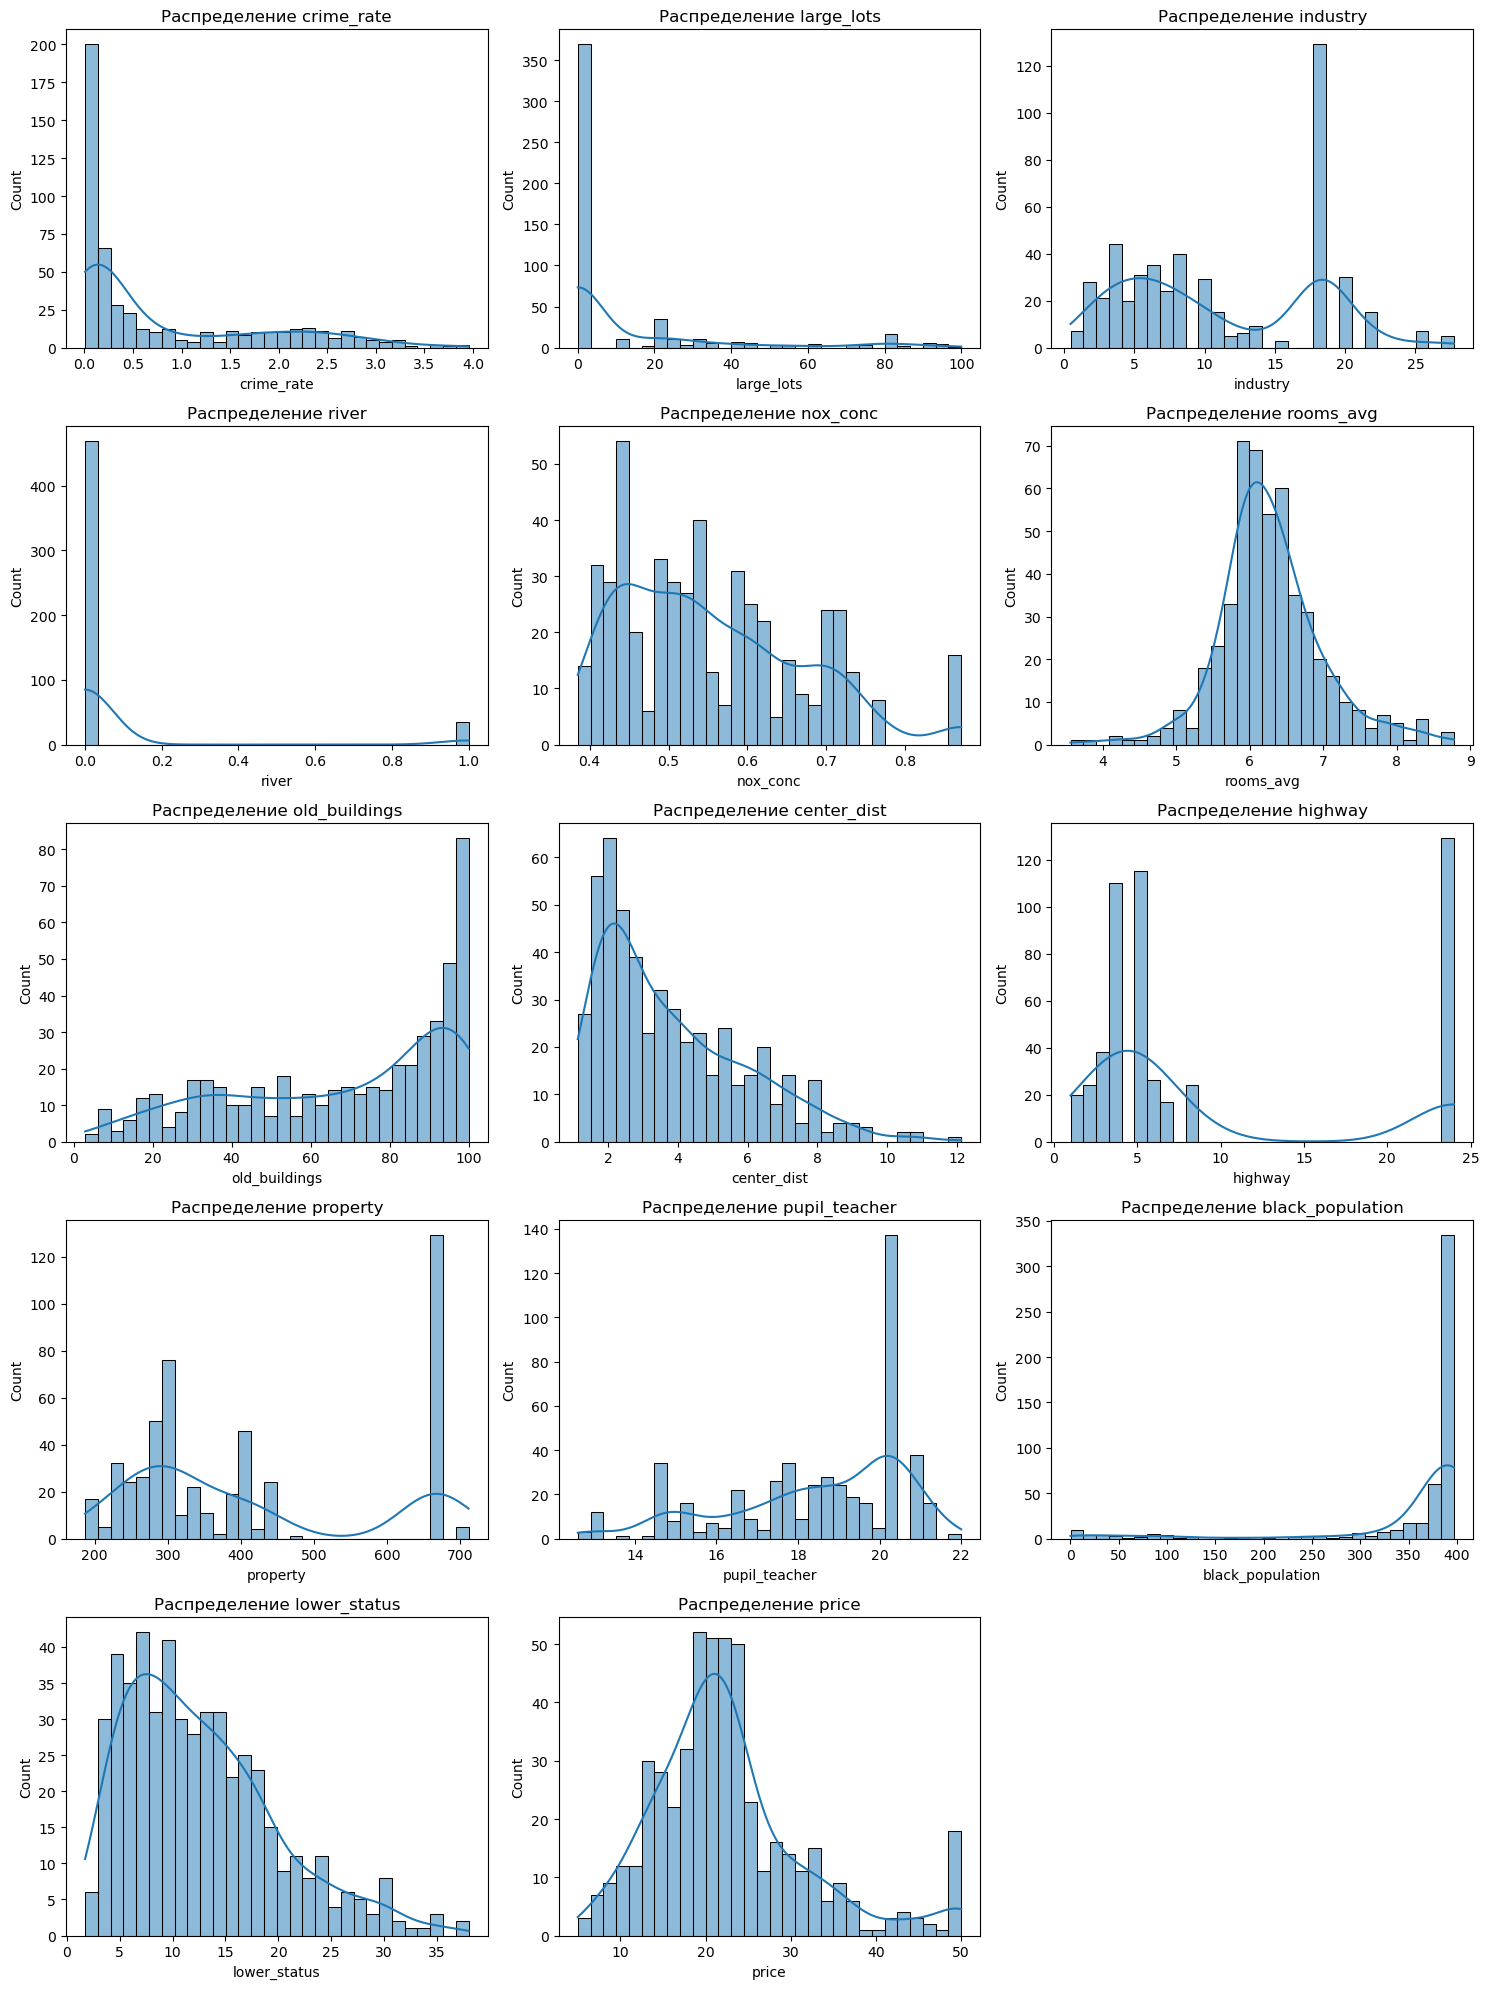

In [35]:
# 1. Считаем количество признаков
n_features = len(numeric_features)
n_cols = 3  # Количество колонок в сетке
n_rows = math.ceil(n_features / n_cols) # Рассчитываем строки (округляем вверх)

# 2. Создаем фигуру с динамическим количеством строк
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten() # Превращаем матрицу в плоский список

for i, col in enumerate(numeric_features):
    sns.histplot(df_global[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение {col}')

# 3. Удаляем пустые графики, если признаков меньше, чем ячеек (например, 7 признаков в сетке 3x3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

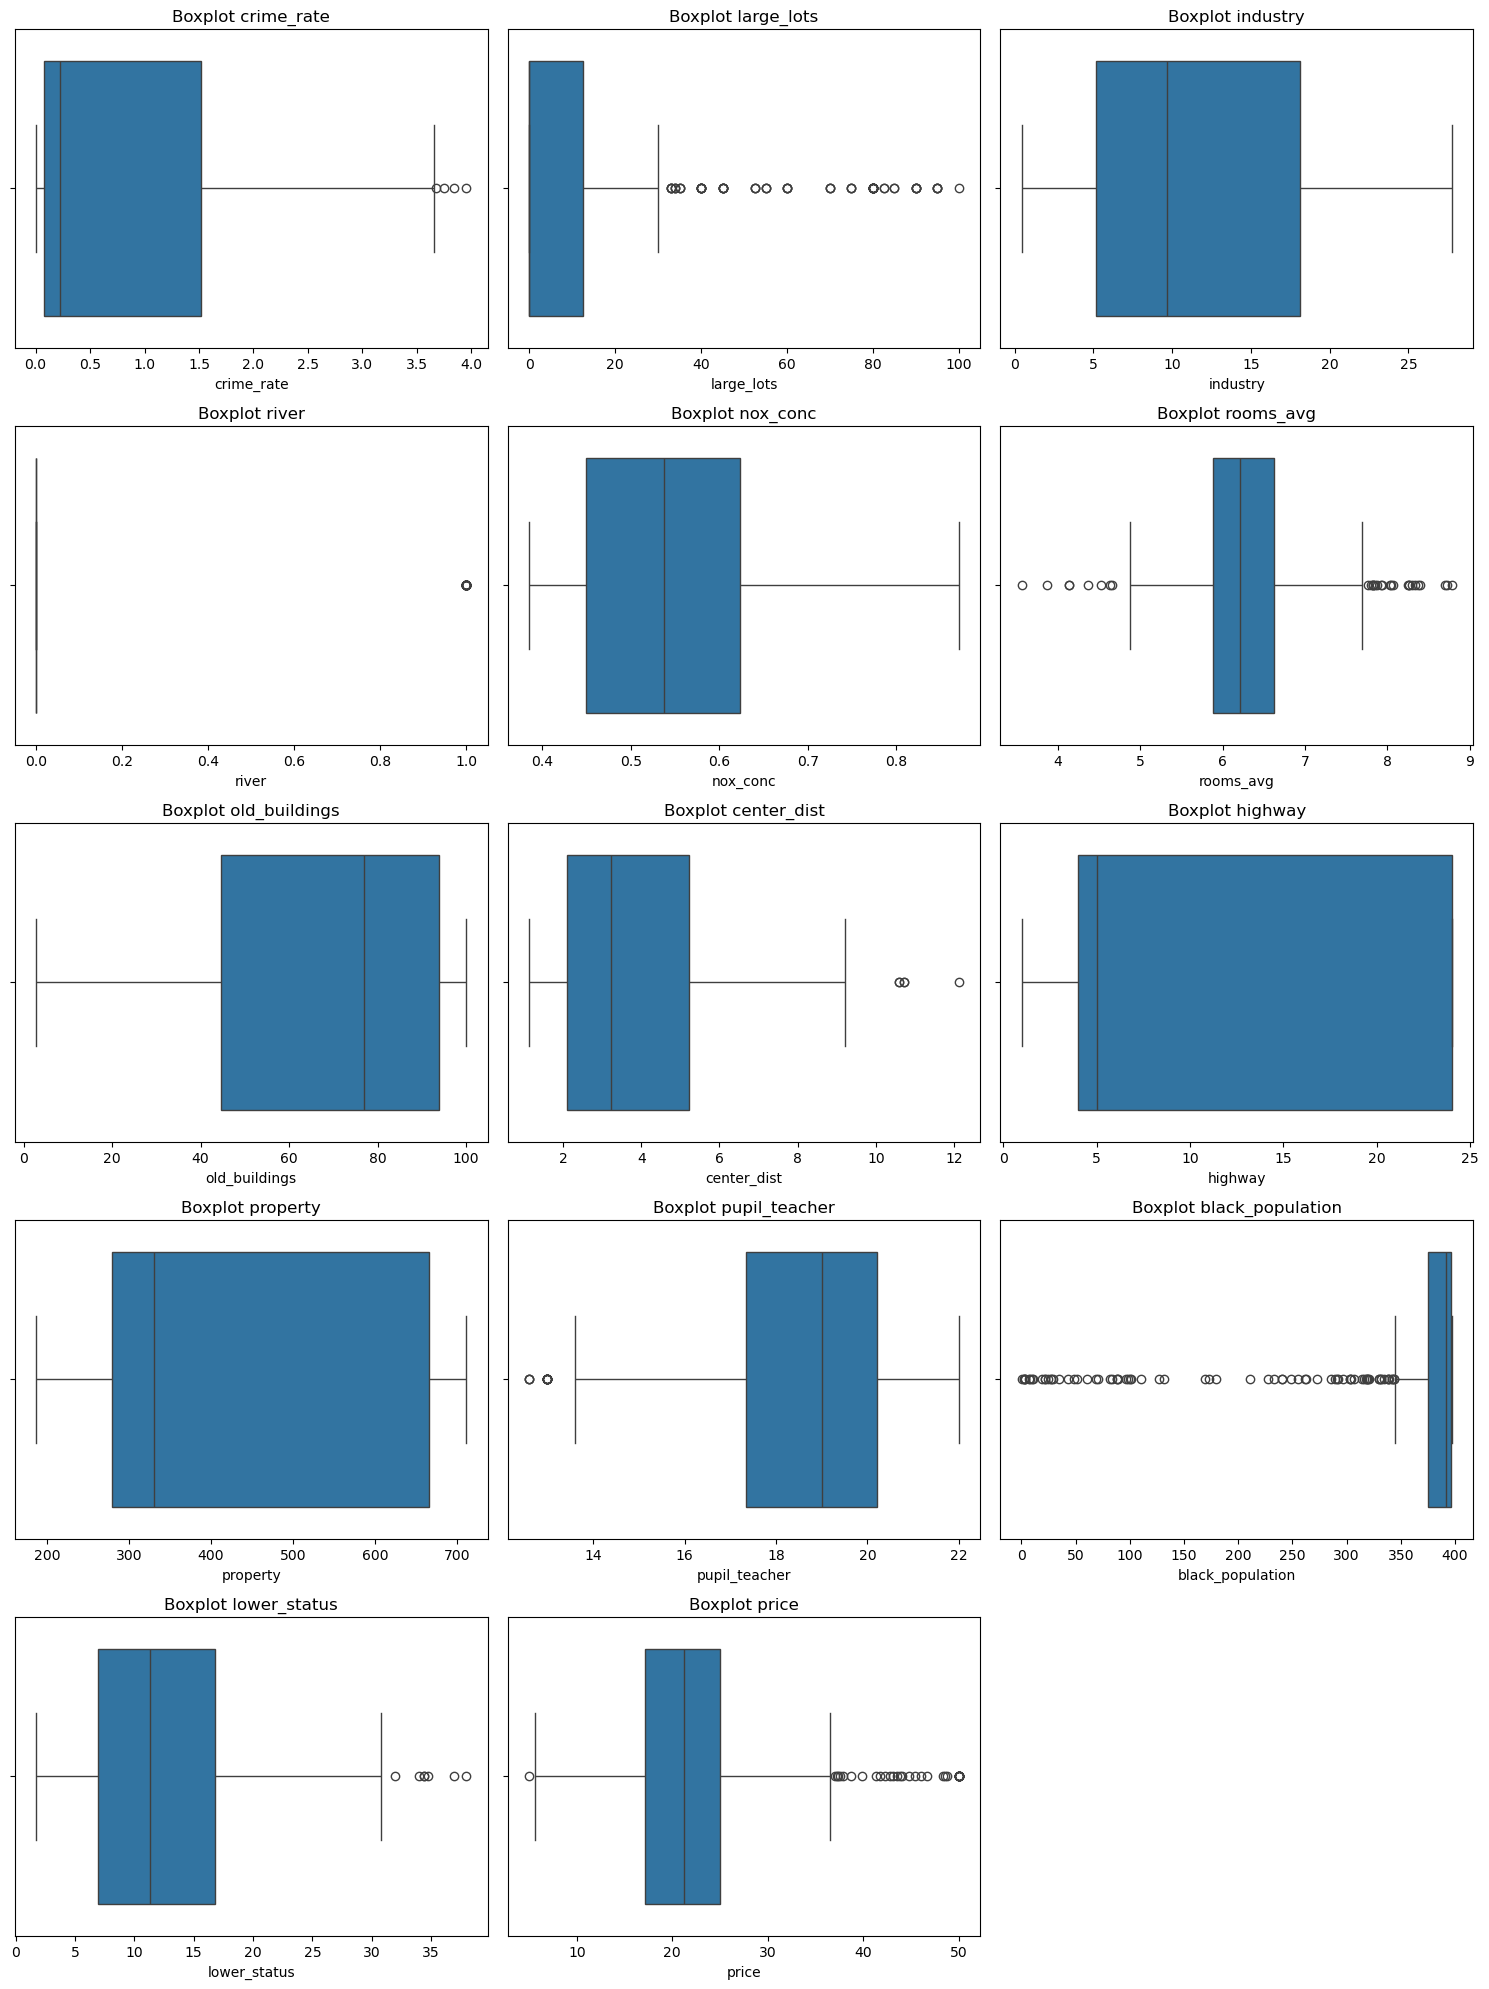

In [36]:
# Создаем сетку, используя уже рассчитанные n_rows и n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(x=df_global[col], ax=axes[i])
    axes[i].set_title(f'Boxplot {col}')

# Удаляем пустые ячейки (если количество признаков не кратно n_cols)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Собираем все этапы воедино

In [37]:
df_global = pd.read_csv('data/BostonHousing.csv')

df_global = df_global.rename(columns={
    'crim': 'crime_rate',           # Уровень преступности
    'zn': 'large_lots',              # Доля земли под большие участки
    'indus': 'industry',             # Доля промышленности
    'chas': 'river',                  # У реки (Charles river)
    'nox': 'nox_conc',       # Концентрация оксидов азота
    'rm': 'rooms_avg',                # Среднее число комнат
    'age': 'old_buildings',           # Доля старых домов (до 1940)
    'dis': 'center_dist',  # Расстояние до центров занятости
    'rad': 'highway',          # Доступ к шоссе
    'tax': 'property',            # Налог на недвижимость
    'ptratio': 'pupil_teacher', # Соотношение ученики/учитель
    'b': 'black_population',    # Индекс чернокожего населения 
    'lstat': 'lower_status',  # % населения с низким статусом
    'medv': 'price'                    # ЦЕЛЬ: медианная цена дома
})
df_global = df_global.dropna()
X = pd.get_dummies(df_global.drop('price', axis=1), drop_first=True) ######### нафиг тут get_dummies
y = df_global['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model_raw = LinearRegression()
model_raw.fit(X_train, y_train)

raw_score = model_raw.score(X_test, y_test)
print(f"Базовая модель R²: {raw_score:.3f}")

Базовая модель R²: 0.751


In [38]:
df_improved = df_global.copy()

# Логарифмы
df_improved['crime_rate_log'] = np.log1p(df_improved['crime_rate'])
df_improved['lower_status_log'] = np.log1p(df_improved['lower_status'])
df_improved['property_log'] = np.log1p(df_improved['property'])

# Бинарные признаки
df_improved['high_crime'] = (df_improved['crime_rate'] > df_improved['crime_rate'].quantile(0.95)).astype(int)
df_improved['many_rooms'] = (df_improved['rooms_avg'] > 7).astype(int)

In [39]:
X_imp = pd.get_dummies(df_improved.drop('price', axis=1), drop_first=True)
y_imp = np.log1p(df_improved['price'])

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_imp, y_imp, test_size=0.3, random_state=42
)

scaler = StandardScaler() 
X_train_imp = scaler.fit_transform(X_train_imp)
X_test_imp = scaler.transform(X_test_imp)

model_imp = LinearRegression()
model_imp.fit(X_train_imp, y_train_imp)

imp_score = model_imp.score(X_test_imp, y_test_imp)

In [40]:
print(f"{'Модель':<30} {'R²':<10}")
print(f"{'Базовая':<30} {raw_score:.3f}")
print(f"{'Улучшенная':<30} {imp_score:.3f}")
print(f"{'Прирост':<30} {imp_score - raw_score:+.3f}")

Модель                         R²        
Базовая                        0.751
Улучшенная                     0.797
Прирост                        +0.046
